# Notebook 02: Feature Engineering

**Project:** MAP Dryer AI  
**Purpose:** transform the deduplicated dryer prototype into a consistent, model-ready feature table.

The notebook standardises data types, builds a timestamp, prepares a complete-case table, explores baseline relationships, and derives process-informed features.

## Inputs and outputs

- **Input:** `data/processed/dryerMAP_prototype_deduplicated_2.xlsx` (created in Notebook 01)
- **Output:** `data/processed/dryerMAP_prototype_processed_2.csv`
- **Figure outputs:** `figures/02_Feature_Engineering/`
- **Prototype feature dictionary:** `config/data_dictionary.yaml`

## Reading guide

All transformations are applied in sequence. The final export is the hand-off artifact for Notebooks 03 and 04.


## 1. Import analysis libraries

Load the libraries needed for data handling, visualisation, statistics, and the downstream modelling workflow.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.feature_catalog import (
    feature_axis_label,
    load_feature_catalog,
    select_feature_catalog,
)
from data.project_paths import find_project_root
from features.engineering import recompute_engineered_features
from features.engineering import ENGINEERED_FEATURES

PROJECT_ROOT = find_project_root()
FIGURE_OUTPUT_DIR = PROJECT_ROOT / "figures" / "02_Feature_Engineering"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DICTIONARY_PATH = PROJECT_ROOT / "config" / "data_dictionary.yaml"
feature_catalog = load_feature_catalog(DATA_DICTIONARY_PATH)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Prototype feature dictionary


In [2]:
FEATURE_ENGINEERING_FIELDS = [
    "date", "time", "timestamp", "dryer_air_temperature",
    "cooler_air_temperature", "air_flow_rate", "wet_product_feed_rate",
    "product_inlet_temperature", "residence_time", "vacuum",
    "steam_pressure", "fan_speed", "product_density",
    "final_product_temp", "final_moisture_h₂o", "temperature_drop",
    "air_product_delta", "air_per_feed", "steam_temp_interaction",
    "heating_index",
]
display(select_feature_catalog(feature_catalog, FEATURE_ENGINEERING_FIELDS))
print("Data dictionary version:", feature_catalog.attrs["version"])


,display_name,unit,unit_status,role,interpretation
feature,,,,,
date,Date,calendar date,defined,identifier,Calendar component of the observation timestamp.
time,Time,clock time,defined,identifier,Clock component of the observation timestamp.
timestamp,Timestamp,datetime,defined,identifier,Date and time combined for chronological order...
dryer_air_temperature,Dryer air temperature,°C,prototype_unit,process_input,Dryer inlet-air temperature.
cooler_air_temperature,Cooler air temperature,°C,prototype_unit,process_input,Cooling-air temperature.
air_flow_rate,Air flow rate,m³/h,defined,process_input,Volumetric airflow rate in cubic metres per hour.
wet_product_feed_rate,Wet product feed rate,m³/h,defined,process_input,Volumetric wet-product feed rate in cubic metr...
product_inlet_temperature,Product inlet temperature,°C,prototype_unit,process_input,Product temperature at dryer entry.
residence_time,Residence time,min,prototype_unit,process_input,Time spent in the drying process.


Data dictionary version: map_dryer_data_dictionary_v1.2


### Interpretation guardrails

- The complete-case table contains only rows with every required modelling value present; the number removed is printed explicitly.
- Pearson correlation describes linear association, not causation.
- `air_per_feed`, `steam_temp_interaction`, and `heating_index` are calculated model features; their formulas and prototype units are shown above.


## 2. Load the deduplicated dataset

Find the project root dynamically, then load the output of Notebook 01. The dataset structure is displayed before any further transformation.


In [3]:
DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_deduplicated_2.xlsx"
)
OUTPUT_PATH = (
    PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_processed_2.csv"
)

dryerMAP = pd.read_excel(DATA_PATH)
dryerMAP.info()


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1080 non-null   datetime64[us]
 1   time                       1080 non-null   str           
 2   dryer_air_temperature      1080 non-null   float64       
 3   cooler_air_temperature     1080 non-null   float64       
 4   air_flow_rate              1080 non-null   float64       
 5   wet_product_feed_rate      1080 non-null   float64       
 6   product_inlet_temperature  1080 non-null   float64       
 7   residence_time             1080 non-null   float64       
 8   vacuum                     1080 non-null   float64       
 9   steam_pressure             1080 non-null   float64       
 10  fan_speed                  1080 non-null   int64         
 11  product_density            1080 non-null   float64       
 12  final_product_tem

## 3. Standardise data types and create a timestamp

Convert the date, time, target, and selected process variables to suitable numeric or temporal types. Combining the date and time fields creates a single chronological `timestamp` for later time-aware analysis.


In [4]:
dryerMAP["date"] = pd.to_datetime(
    dryerMAP["date"],
    dayfirst=True
)


In [5]:
dryerMAP["time"] = pd.to_datetime(
    dryerMAP["time"],
    format="%H:%M:%S"
).dt.time


In [6]:
dryerMAP["timestamp"] = pd.to_datetime(
    dryerMAP["date"].dt.strftime("%Y-%m-%d") + " " + dryerMAP["time"].astype(str)
)


In [7]:
dryerMAP["product_density"] = pd.to_numeric(
    dryerMAP["product_density"],
    errors="coerce"
)


In [8]:
dryerMAP["final_moisture_h₂o"] = pd.to_numeric(
    dryerMAP["final_moisture_h₂o"],
    errors="coerce"
)


In [9]:
cols = [
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed"
]

dryerMAP[cols] = dryerMAP[cols].astype(float)


## 4. Verify the transformed dataset

Review the resulting column types and non-null counts after standardisation. This confirms that the fields used in the next steps have the expected representation.


In [10]:
dryerMAP.info()


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1080 non-null   datetime64[us]
 1   time                       1080 non-null   object        
 2   dryer_air_temperature      1080 non-null   float64       
 3   cooler_air_temperature     1080 non-null   float64       
 4   air_flow_rate              1080 non-null   float64       
 5   wet_product_feed_rate      1080 non-null   float64       
 6   product_inlet_temperature  1080 non-null   float64       
 7   residence_time             1080 non-null   float64       
 8   vacuum                     1080 non-null   float64       
 9   steam_pressure             1080 non-null   float64       
 10  fan_speed                  1080 non-null   float64       
 11  product_density            1080 non-null   float64       
 12  final_product_tem

## 5. Create the complete-case modelling table

Rows with missing values are removed to form `dryerMAP_model`. The printed counts make the impact of this modelling choice explicit.


In [11]:
print(f"Original dataset: {len(dryerMAP)} rows")

dryerMAP_model = dryerMAP.dropna(subset=dryerMAP.columns.tolist()).copy()

print(f"Clean dataset: {len(dryerMAP_model)} rows")

print(f"Rows removed: {len(dryerMAP)-len(dryerMAP_model)}")


Original dataset: 1080 rows
Clean dataset: 1080 rows
Rows removed: 0


## 6. Inspect distributions before modelling

A boxplot gives a quick visual check of scale, spread, and potential outliers across the available numerical variables.


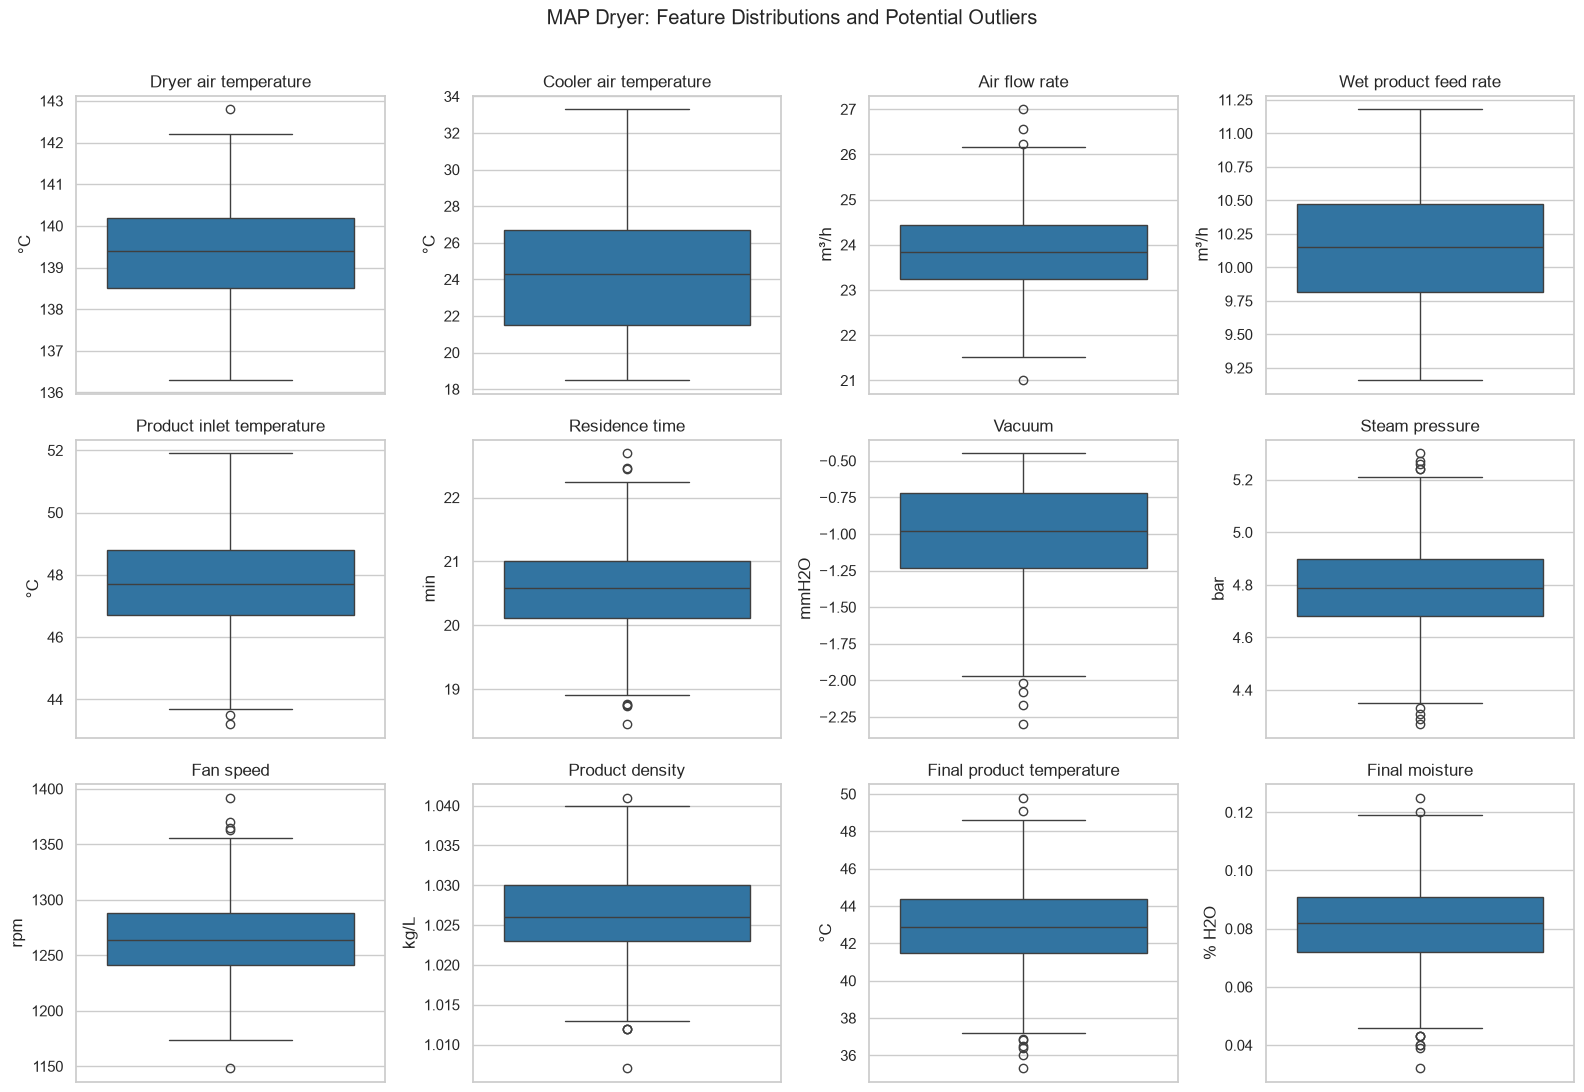

In [12]:
numeric_features = [
    feature
    for feature in dryerMAP_model.select_dtypes(include="number").columns
    if feature in feature_catalog.index
]
n_columns = 4
n_rows = int(np.ceil(len(numeric_features) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 3.6 * n_rows))
axes = np.asarray(axes).reshape(-1)

for axis, feature in zip(axes, numeric_features):
    sns.boxplot(y=dryerMAP_model[feature], color="tab:blue", ax=axis)
    axis.set_title(feature_catalog.loc[feature, "display_name"])
    axis.set_ylabel(feature_catalog.loc[feature, "unit"])
    axis.set_xlabel("")
for axis in axes[len(numeric_features):]:
    axis.set_visible(False)

fig.suptitle("MAP Dryer: Feature Distributions and Potential Outliers", y=1.01)
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 7. Establish baseline correlations

Calculate and visualise Pearson correlations among numeric variables. This is exploratory evidence, not a claim of causation, and helps identify relationships worth examining during modelling.


C:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()


C:\Users\pc\AppData\Local\Temp\ipykernel_27792\3198461703.py:10: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(


C:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


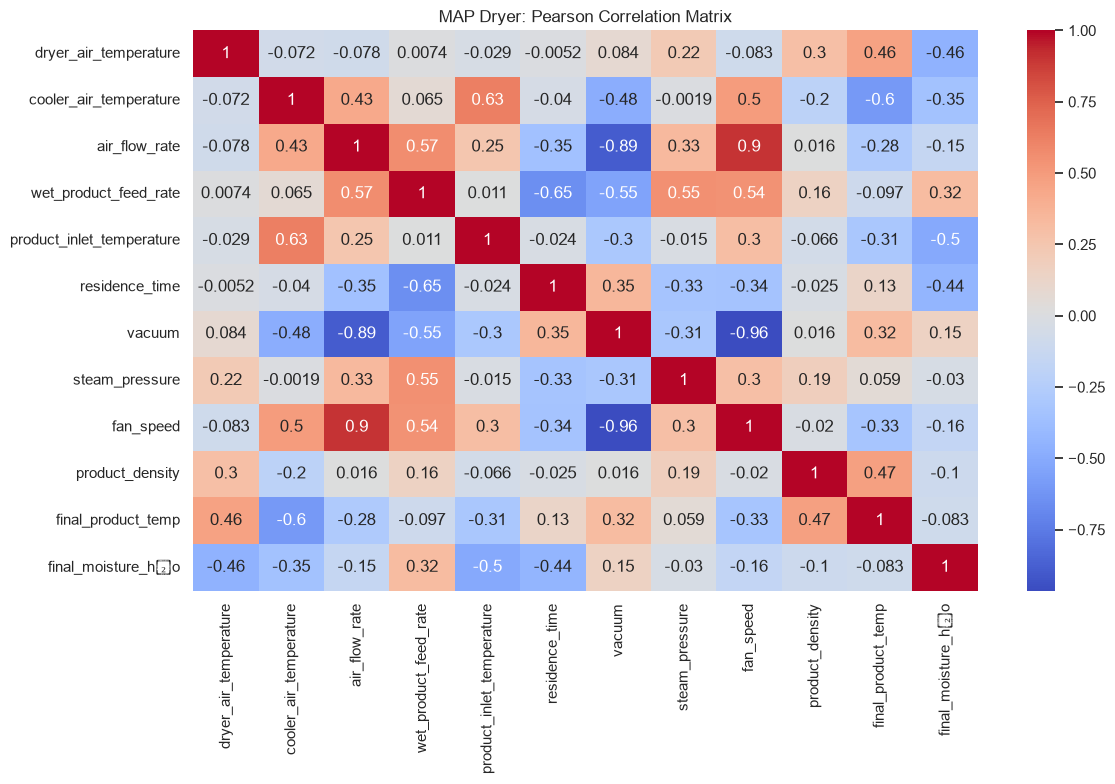

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    dryerMAP_model.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("MAP Dryer: Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "02_pearson_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 8. Examine relationships with the quality target

Convert the final-moisture target to numeric form and rank its linear correlations with the available numeric variables. This provides a baseline before engineered features are added.


In [14]:
target = next(c for c in dryerMAP.columns if "final_moisture" in c)

dryerMAP[target] = pd.to_numeric(
    dryerMAP[target].astype(str).str.replace("%", "", regex=False),
    errors="coerce",
)
corr_with_target = (
    dryerMAP.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

print(corr_with_target)


final_moisture_h₂o           1.000000
wet_product_feed_rate        0.320521
vacuum                       0.154758
steam_pressure              -0.030437
final_product_temp          -0.083104
product_density             -0.102130
air_flow_rate               -0.145259
fan_speed                   -0.162518
cooler_air_temperature      -0.349857
residence_time              -0.437682
dryer_air_temperature       -0.457609
product_inlet_temperature   -0.504379
Name: final_moisture_h₂o, dtype: float64


## 9. Create process-informed features

The following derived variables express useful process relationships:

- `temperature_drop`: dryer-air temperature minus final-product temperature
- `air_product_delta`: dryer-air temperature minus product-inlet temperature
- `air_per_feed`: air-flow rate per wet-product feed rate
- `steam_temp_interaction`: steam pressure multiplied by dryer-air temperature
- `heating_index`: residence time multiplied by dryer-air temperature

The shared `features.engineering` transformation creates all five columns in one reproducible step.


In [15]:
dryerMAP_model = recompute_engineered_features(dryerMAP_model)
display(dryerMAP_model[list(ENGINEERED_FEATURES)].head())


,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,98.0,91.3,2.362000,651.910,2913.440
1,96.0,93.1,2.384314,667.766,2834.513
2,94.4,92.8,2.321951,673.881,2852.436
3,94.5,91.6,2.273612,666.369,2828.925
4,96.9,93.3,2.264734,676.632,2934.402


## 10. Inspect the engineered feature table

List the final columns and preview the first records to confirm that the derived variables were added as intended.


In [16]:
dryerMAP_model.columns.tolist()


['date',
 'time',
 'dryer_air_temperature',
 'cooler_air_temperature',
 'air_flow_rate',
 'wet_product_feed_rate',
 'product_inlet_temperature',
 'residence_time',
 'vacuum',
 'steam_pressure',
 'fan_speed',
 'product_density',
 'final_product_temp',
 'final_moisture_h₂o',
 'timestamp',
 'temperature_drop',
 'air_product_delta',
 'air_per_feed',
 'steam_temp_interaction',
 'heating_index']

In [17]:
dryerMAP_model.head()


,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,2026-04-23,01:00:00,139.0,23.2,23.62,10.00,47.7,20.96,-1.18,4.69,1270.0,1.023,41.0,0.075,2026-04-23 01:00:00,98.0,91.3,2.362000,651.910,2913.440
1,2026-04-23,03:00:00,139.7,21.4,24.32,10.20,46.6,20.29,-0.63,4.78,1236.0,1.028,43.7,0.087,2026-04-23 03:00:00,96.0,93.1,2.384314,667.766,2834.513
2,2026-04-23,05:00:00,140.1,18.9,23.80,10.25,47.3,20.36,-1.08,4.81,1272.0,1.034,45.7,0.072,2026-04-23 05:00:00,94.4,92.8,2.321951,673.881,2852.436
3,2026-04-23,07:00:00,139.7,18.5,23.35,10.27,48.1,20.25,-0.65,4.77,1238.0,1.033,45.2,0.094,2026-04-23 07:00:00,94.5,91.6,2.273612,666.369,2828.925
4,2026-04-23,09:00:00,139.8,19.0,23.44,10.35,46.5,20.99,-1.10,4.84,1267.0,1.025,42.9,0.084,2026-04-23 09:00:00,96.9,93.3,2.264734,676.632,2934.402


## 11. Visualise and rank engineered features

Plot each engineered feature against final moisture, then rank all numeric features by the absolute size of their Pearson correlation with the target. These views help prioritise candidates for the soft-sensor models.


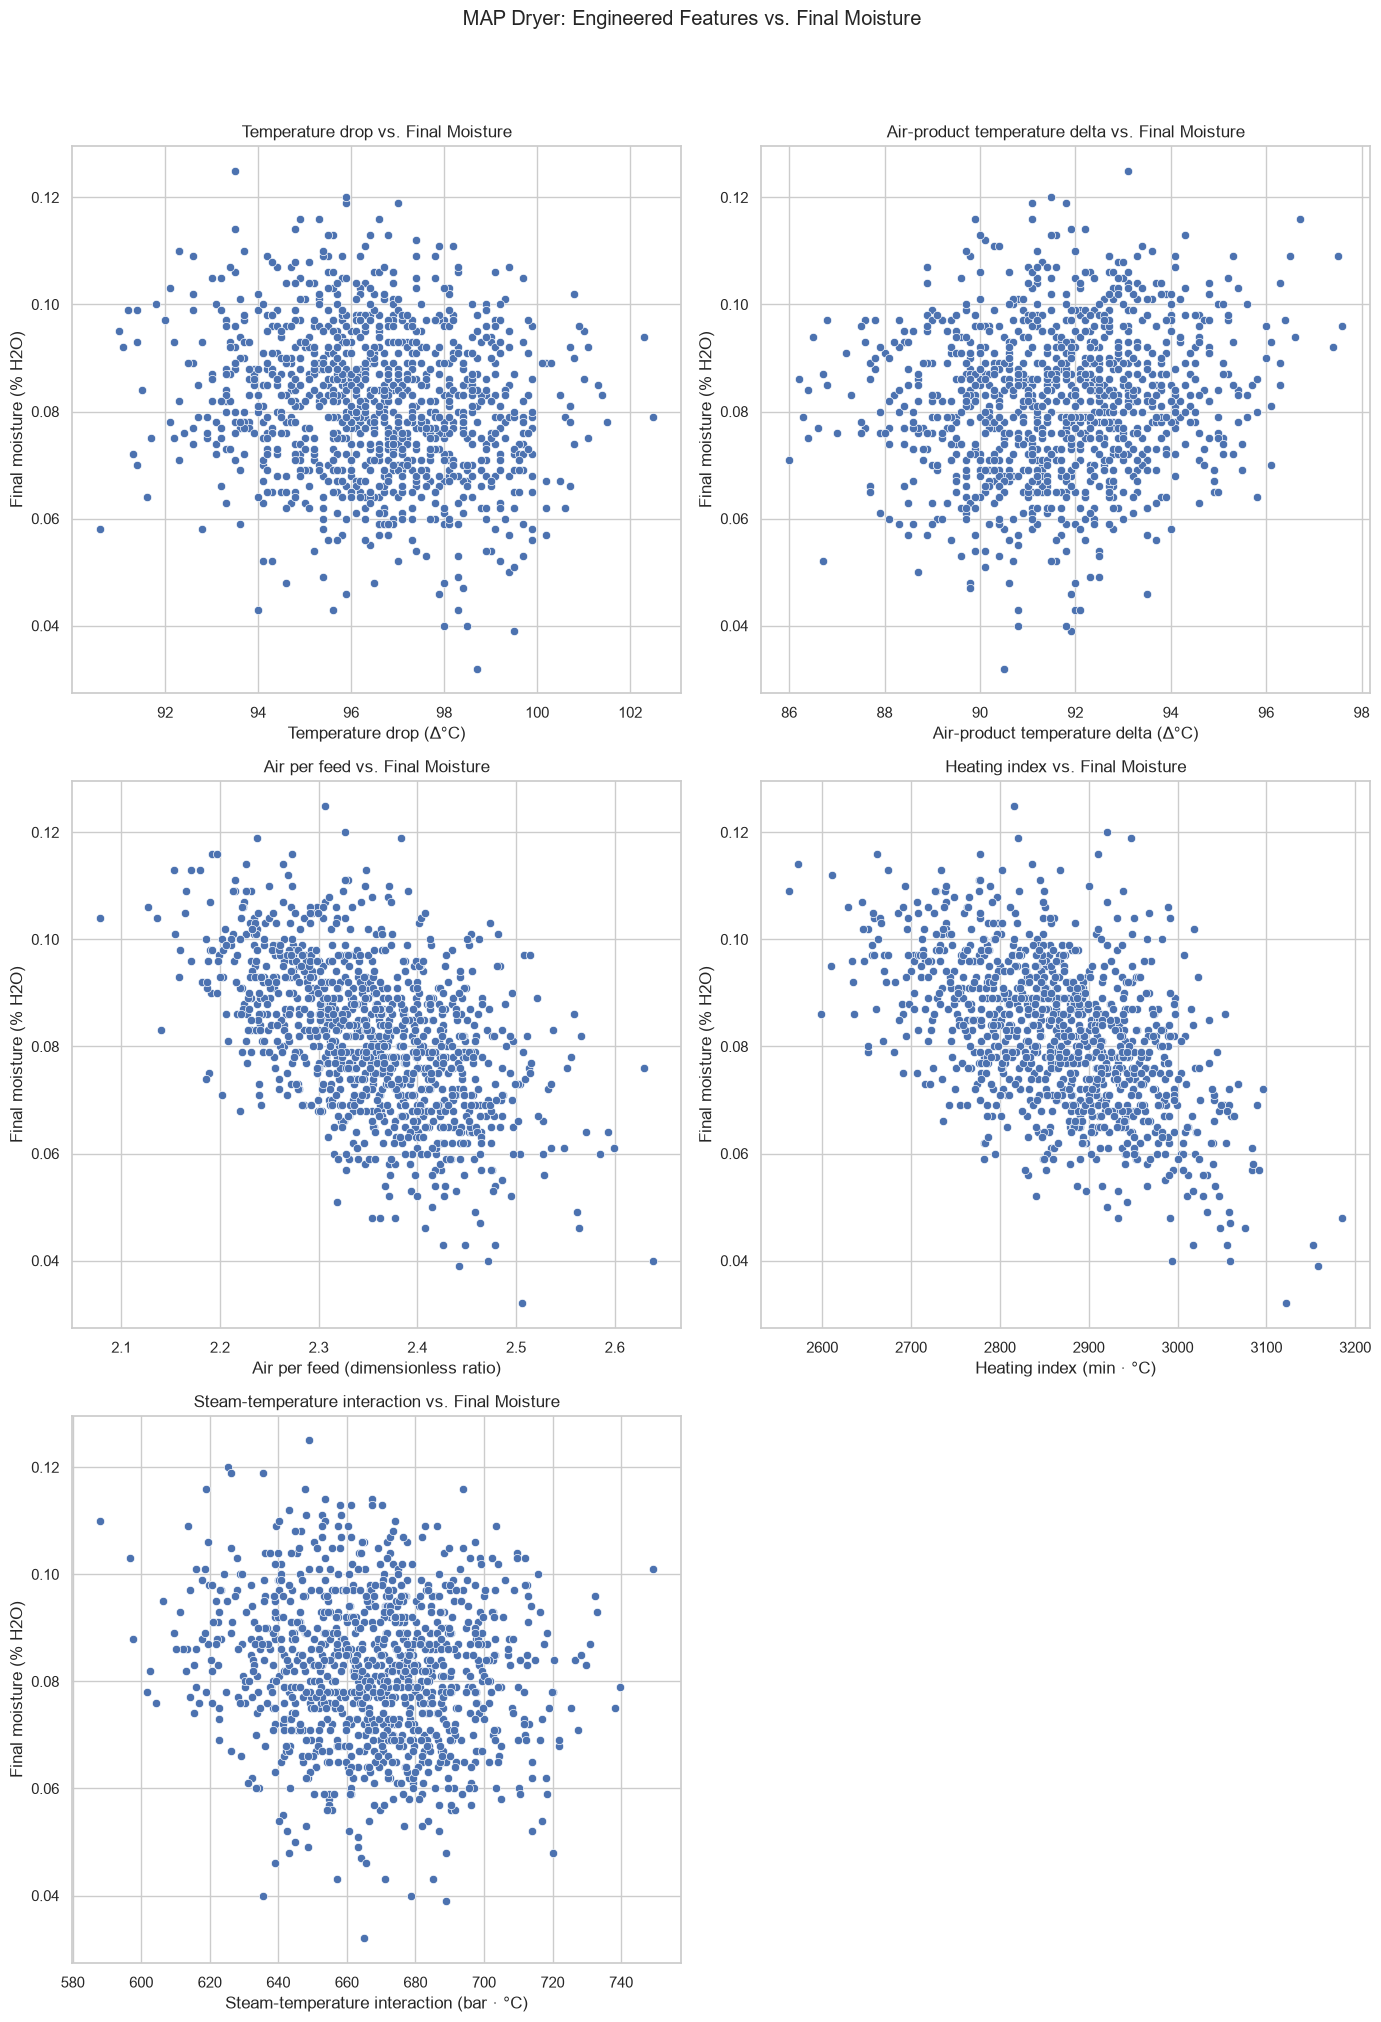

In [18]:
engineered_features = [
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "heating_index",
    "steam_temp_interaction"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 20))
fig.suptitle("MAP Dryer: Engineered Features vs. Final Moisture", y=1.01)
axes = axes.flatten()

for ax, feature in zip(axes, engineered_features):
    sns.scatterplot(
        data=dryerMAP_model,
        x=feature,
        y="final_moisture_h₂o",
        ax=ax
    )
    display_name = feature_catalog.loc[feature, "display_name"]
    ax.set_title(f"{display_name} vs. Final Moisture")
    ax.set_xlabel(feature_axis_label(feature_catalog, feature))
    ax.set_ylabel(feature_axis_label(feature_catalog, "final_moisture_h₂o"))

for ax in axes[len(engineered_features):]:
    ax.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(
    FIGURE_OUTPUT_DIR / "03_engineered_features_vs_final_moisture.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [19]:
corr = dryerMAP_model.corr(numeric_only=True)["final_moisture_h₂o"]

corr_df = (
    corr.drop("final_moisture_h₂o")
        .to_frame(name="Correlation")
)

corr_df["Absolute Correlation"] = corr_df["Correlation"].abs()

corr_df = corr_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

display(corr_df)


,Correlation,Absolute Correlation
heating_index,-0.537080,0.537080
air_per_feed,-0.507650,0.507650
product_inlet_temperature,-0.504379,0.504379
dryer_air_temperature,-0.457609,0.457609
residence_time,-0.437682,0.437682
cooler_air_temperature,-0.349857,0.349857
wet_product_feed_rate,0.320521,0.320521
temperature_drop,-0.164534,0.164534
fan_speed,-0.162518,0.162518
vacuum,0.154758,0.154758


## 12. Export the model-ready dataset

Write the completed feature table to the processed-data directory. This CSV is the hand-off artifact for the soft-sensor modelling notebook.


In [20]:
dryerMAP_model.to_csv(OUTPUT_PATH, index=False)
print(f"Exported model-ready data to {OUTPUT_PATH}")


Exported model-ready data to C:\Users\pc\Documents\GitHub\PROJECTS\MAP-Dryer-AI\data\processed\dryerMAP_prototype_processed_2.csv


## Next step

Continue with **Notebook 03: Model 1: Soft Sensor** to train and evaluate moisture-prediction models using this processed dataset.
